<a href="https://colab.research.google.com/github/iortcacha/dotfiles/blob/master/B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [114]:
import pandas as pd
import numpy as np

transactions = pd.read_csv("transactions.csv")
users = pd.read_csv("users.csv")
fraudsters = pd.read_csv("fraudsters.csv")
fx_rates = pd.read_csv("fx_rates.csv")
currency_details = pd.read_csv("currency_details.csv")
countries = pd.read_csv("countries.csv")

transactions.columns = transactions.columns.str.lower()
users.columns = users.columns.str.lower()

In [115]:
# Data cleaning

transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688651 entries, 0 to 688650
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   unnamed: 0         688651 non-null  int64 
 1   currency           688651 non-null  object
 2   amount             688651 non-null  int64 
 3   state              688651 non-null  object
 4   created_date       688651 non-null  object
 5   merchant_category  223065 non-null  object
 6   merchant_country   483073 non-null  object
 7   entry_method       688651 non-null  object
 8   user_id            688651 non-null  object
 9   type               688651 non-null  object
 10  source             688651 non-null  object
 11  id                 688651 non-null  object
dtypes: int64(2), object(10)
memory usage: 63.0+ MB


In [116]:
# Dates in correct type
transactions["created_date"] = pd.to_datetime(transactions["created_date"])

In [117]:
# Check for missing data

transactions.isna().sum()

,0
unnamed: 0,0
currency,0
amount,0
state,0
created_date,0
merchant_category,465586
merchant_country,205578
entry_method,0
user_id,0
type,0


In [118]:
# Check negative transactions
(transactions["amount"] < 0).sum()


np.int64(0)

In [119]:
# Clean working table
tx = transactions.copy()

In [120]:
# Normalize the amount
tx = tx.merge(
    currency_details[["currency", "exponent"]],
    on="currency",
    how="left"
)

tx["exponent"] = tx["exponent"].fillna(2)
tx["amount_real"] = tx["amount"] / (10 ** tx["exponent"])

In [121]:
# User features

user_features = tx.groupby("user_id").agg(
    total_amount=("amount_real", "sum"),
    num_transactions=("id", "count")
).reset_index()

In [122]:
# Transaction type behaviour

type_counts = pd.crosstab(tx["user_id"], tx["type"])
type_counts = type_counts.reset_index()

In [123]:
# Failed ratio
state_counts = pd.crosstab(tx["user_id"], tx["state"])
state_counts = state_counts.reset_index()
state_counts["failed_ratio"] = (
    state_counts.get("FAILED", 0) / state_counts.drop(columns="user_id").sum(axis=1)
)

In [124]:
# Geographic behaviour

country_counts = tx.groupby("user_id")["merchant_country"].nunique().reset_index()
country_counts.columns = ["user_id", "num_countries"]

In [125]:
# Average time between transactions

tx = tx.sort_values(["user_id", "created_date"])

tx["prev_time"] = tx.groupby("user_id")["created_date"].shift(1)

tx["time_diff"] = (
    tx["created_date"] - tx["prev_time"]
).dt.total_seconds()

velocity = tx.groupby("user_id")["time_diff"].mean().reset_index()
velocity.columns = ["user_id", "avg_time_between_tx"]


In [126]:
# merge all features

df = user_features.copy()

df = df.merge(type_counts, on="user_id", how="left")
df = df.merge(state_counts[["user_id", "failed_ratio"]], on="user_id", how="left")
df = df.merge(country_counts, on="user_id", how="left")
df = df.merge(velocity, on="user_id", how="left")
df = df.fillna(0)

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8021 entries, 0 to 8020
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              8021 non-null   object 
 1   total_amount         8021 non-null   float64
 2   num_transactions     8021 non-null   int64  
 3   ATM                  8021 non-null   int64  
 4   BANK_TRANSFER        8021 non-null   int64  
 5   CARD_PAYMENT         8021 non-null   int64  
 6   P2P                  8021 non-null   int64  
 7   TOPUP                8021 non-null   int64  
 8   failed_ratio         8021 non-null   float64
 9   num_countries        8021 non-null   int64  
 10  avg_time_between_tx  8021 non-null   float64
dtypes: float64(3), int64(7), object(1)
memory usage: 689.4+ KB


In [128]:
# Add fraud label

df["is_fraud"] = df["user_id"].isin(fraudsters["user_id"]).astype(int)

# check class inbalance
df["is_fraud"].value_counts()

,count
is_fraud,
0,7722
1,299


In [129]:
# 1st model : Logistic regression

X = df.drop(columns=["user_id", "is_fraud"])
y = df["is_fraud"]

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [131]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [132]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000,class_weight="balanced")

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [133]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.70      0.82      1545
           1       0.09      0.78      0.16        60

    accuracy                           0.70      1605
   macro avg       0.54      0.74      0.49      1605
weighted avg       0.95      0.70      0.80      1605



In [134]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})
feature_importance["abs_coef"] = feature_importance["coefficient"].abs()

feature_importance.sort_values(by="abs_coef", ascending=False)

,feature,coefficient,abs_coef
8,num_countries,-1.367696,1.367696
4,CARD_PAYMENT,-0.981488,0.981488
2,ATM,0.968628,0.968628
9,avg_time_between_tx,-0.960515,0.960515
3,BANK_TRANSFER,0.917250,0.917250
5,P2P,-0.658068,0.658068
1,num_transactions,-0.642148,0.642148
6,TOPUP,0.211760,0.211760
7,failed_ratio,-0.206872,0.206872
0,total_amount,-0.069697,0.069697


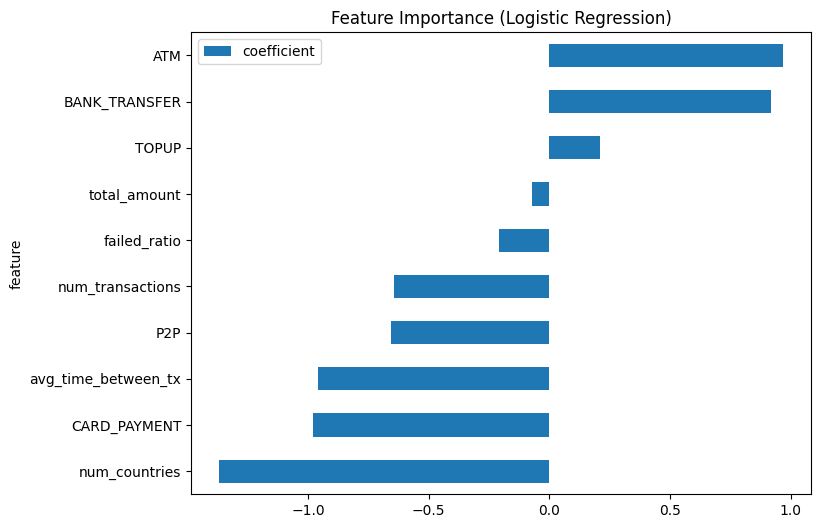

In [135]:
import matplotlib.pyplot as plt

feature_importance.sort_values(by="coefficient").plot(
    x="feature",
    y="coefficient",
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance (Logistic Regression)")
plt.show()

I analyzed the model coefficients to understand the drivers of fraud prediction. Transaction types such as ATM withdrawals and bank transfers showed the strongest positive association with fraud risk, while features like transaction frequency and time between transactions were negatively associated. Interestingly, geographic spread appeared negatively correlated with fraud in this dataset, suggesting that fraudulent users may operate in more localized patterns.

In [136]:
df_candidates = df[~df["user_id"].isin(fraudsters["user_id"])]

df["fraud_probability"] = model.predict_proba(
    scaler.transform(X)
)[:, 1]
top_5 = df_candidates.sort_values(
    "fraud_probability", ascending=False
).head(5)

top_5[["user_id", "fraud_probability"]]

KeyError: 'fraud_probability'

In [ ]:
top_5_details = df[df["user_id"].isin(top_5["user_id"])]
top_5_details

In [ ]:
df.describe()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd

# Model : Random Forest

# Features and target
X_rf = df.drop(columns=["user_id", "is_fraud"])
y_rf = df["is_fraud"]

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y
)

# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred_rf))

In [ ]:
# Predict fraud probability for all users
df["fraud_probability_rf"] = rf_model.predict_proba(X)[:, 1]

# Remove known fraudsters
df_candidates_rf = df[~df["user_id"].isin(fraudsters["user_id"])].copy()

# Top 5 most likely fraudsters
top_5_rf = df_candidates_rf.sort_values(
    "fraud_probability_rf", ascending=False
).head(5)

top_5_rf[["user_id", "fraud_probability_rf"]]

In [ ]:
feature_importance_rf = pd.DataFrame({
    "feature": X_rf.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance_rf

In [ ]:
feature_importance_rf.sort_values(by="importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8, 6)
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()